# Cấu phần (ii) — Model dự đoán giá đối thủ

> **Notebook để TRÌNH BÀY.** Chạy `Run All` ~2 phút, hình cỡ lớn để chiếu.
> Chi tiết kỹ thuật nằm ở `01`–`08` và `train/01`–`06`.

---

## Bài toán

Dự đoán **giá đối thủ sẽ hiện ra** tại thời điểm tương lai, từ thông tin biết trước lúc báo giá.

## Kiến trúc: **Hybrid** — tách làm hai model

```
giá cuối = Model A (giá cơ bản)  ×  Model B (hệ số nhân)
```

Lý do tách xuất phát từ phân tích ở cấu phần (i): **hai bài toán có độ khó khác hẳn nhau**.

| | Dữ liệu giải thích được |
|---|---:|
| Hệ số nhân | **96,6%** |
| Giá cơ bản | **19%** |

Nếu gộp chung thì model phải học đồng thời hai thứ rất khác nhau; tách ra thì mỗi model làm đúng
việc của mình — và quan trọng hơn, **chỉ ra được nút thắt nằm ở đâu**.

## Đã thử những gì

| Nhóm | Thuật toán |
|---|---|
| Boosting tree | HistGB · LightGBM · XGBoost |
| Cộng dồn (giải thích được) | GAM (`pygam`, spline + factor term) |
| Mốc so sánh | Persistence — lấy luôn giá quan sát gần nhất |

Cùng feature contract, cùng giao thức chia dữ liệu theo tháng, cùng tập test **864.360 chuyến**.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 13, "axes.labelsize": 11.5,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5, "legend.fontsize": 10.5,
})
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

uq = pd.read_parquet("uq_pred_test.parquet")
pg = pd.read_parquet("pred_gia.parquet",
                     columns=["split", "algo", "pred", "target_shown_price",
                              "persistence_prediction"])
pg = pg[pg.split == "test"]
gam = pd.read_parquet("pred_gam.parquet",
                      columns=["split", "gia_that", "base_pred", "heso_pred",
                               "hybrid_pred", "truc_tiep_pred"])
gam = gam[gam.split == "test"].reset_index(drop=True)
assert np.allclose(gam.gia_that.values, uq.gia_that.values), "khong khop hang!"

uq["ngay"] = uq.target_timestamp.dt.date
print(f"Tap test: {len(uq):,} chuyen  ·  {uq.ngay.nunique()} ngay  "
      f"({uq.target_timestamp.min():%d/%m} – {uq.target_timestamp.max():%d/%m/%Y})")


def do(p, t):
    p, t = np.asarray(p, float), np.asarray(t, float)
    return dict(MAE=np.abs(p-t).mean(), MAPE=(np.abs(p-t)/t).mean(),
                R2=1-((p-t)**2).sum()/((t-t.mean())**2).sum())

Tap test: 864,360 chuyen  ·  11 ngay  (28/01 – 30/03/2026)


## 1. Bảng kết quả training

In [2]:
rows = []

# --- Nhanh HYBRID (gia co ban x he so nhan) ---
for ten, p, t, dv in [
        ("Hybrid — giá cuối", uq.hybrid_pred, uq.gia_that, "đ"),
        ("  ├─ Model A: giá cơ bản", uq.base_pred, uq.base_that, "đ"),
        ("  └─ Model B: hệ số nhân", uq.heso_pred, uq.heso_that, "×")]:
    m = do(p, t)
    rows.append({"Kiến trúc": "Hybrid (HistGB)", "Nhánh": ten,
                 "MAE": f"{m['MAE']:,.0f}đ" if dv == "đ" else f"{m['MAE']:.4f}",
                 "MAPE": f"{m['MAPE']:.2%}", "R²": round(m["R2"], 4)})

# --- Nhanh TRUC TIEP (3 thuat toan cay) ---
for a, g in pg.groupby("algo", observed=True):
    m = do(g.pred, g.target_shown_price)
    rows.append({"Kiến trúc": "Trực tiếp", "Nhánh": a,
                 "MAE": f"{m['MAE']:,.0f}đ", "MAPE": f"{m['MAPE']:.2%}",
                 "R²": round(m["R2"], 4)})

# --- GAM ---
m = do(gam.truc_tiep_pred, gam.gia_that)
rows.append({"Kiến trúc": "Trực tiếp", "Nhánh": "GAM",
             "MAE": f"{m['MAE']:,.0f}đ", "MAPE": f"{m['MAPE']:.2%}",
             "R²": round(m["R2"], 4)})
m = do(gam.hybrid_pred, gam.gia_that)
rows.append({"Kiến trúc": "Hybrid (GAM)", "Nhánh": "GAM — giá cuối",
             "MAE": f"{m['MAE']:,.0f}đ", "MAPE": f"{m['MAPE']:.2%}",
             "R²": round(m["R2"], 4)})

# --- Moc so sanh ---
g0 = pg[pg.algo == pg.algo.iloc[0]]
m = do(g0.persistence_prediction, g0.target_shown_price)
rows.append({"Kiến trúc": "— Mốc so sánh", "Nhánh": "Persistence",
             "MAE": f"{m['MAE']:,.0f}đ", "MAPE": f"{m['MAPE']:.2%}",
             "R²": round(m["R2"], 4)})

BANG = pd.DataFrame(rows)
display(BANG.style.hide(axis="index"))

mae_hyb = do(uq.hybrid_pred, uq.gia_that)["MAE"]
mae_pers = do(g0.persistence_prediction, g0.target_shown_price)["MAE"]
mae_algo = [do(g.pred, g.target_shown_price)["MAE"] for _, g in pg.groupby("algo", observed=True)]
mae_algo.append(do(gam.truc_tiep_pred, gam.gia_that)["MAE"])
print(f"\nHybrid tot nhat        : {mae_hyb:,.0f}d")
print(f"Vuot persistence       : {(1-mae_hyb/mae_pers)*100:.0f}%")
print(f"4 thuat toan truc tiep : {min(mae_algo):,.0f} – {max(mae_algo):,.0f}d  "
      f"(chenh {(max(mae_algo)/min(mae_algo)-1)*100:.1f}%)")

Kiến trúc,Nhánh,MAE,MAPE,R²
Hybrid (HistGB),Hybrid — giá cuối,"18,048đ",14.74%,0.729700
Hybrid (HistGB),├─ Model A: giá cơ bản,"15,032đ",14.58%,0.656300
Hybrid (HistGB),└─ Model B: hệ số nhân,0.0233,1.91%,0.960600
Trực tiếp,HistGB,"18,834đ",15.36%,0.704700
Trực tiếp,LightGBM,"18,809đ",15.34%,0.705500
Trực tiếp,XGBoost,"18,807đ",15.34%,0.705600
Trực tiếp,GAM,"19,173đ",15.70%,0.697700
Hybrid (GAM),GAM — giá cuối,"18,242đ",15.02%,0.728600
— Mốc so sánh,Persistence,"33,683đ",28.18%,0.019100



Hybrid tot nhat        : 18,048d
Vuot persistence       : 46%
4 thuat toan truc tiep : 18,807 – 19,173d  (chenh 1.9%)


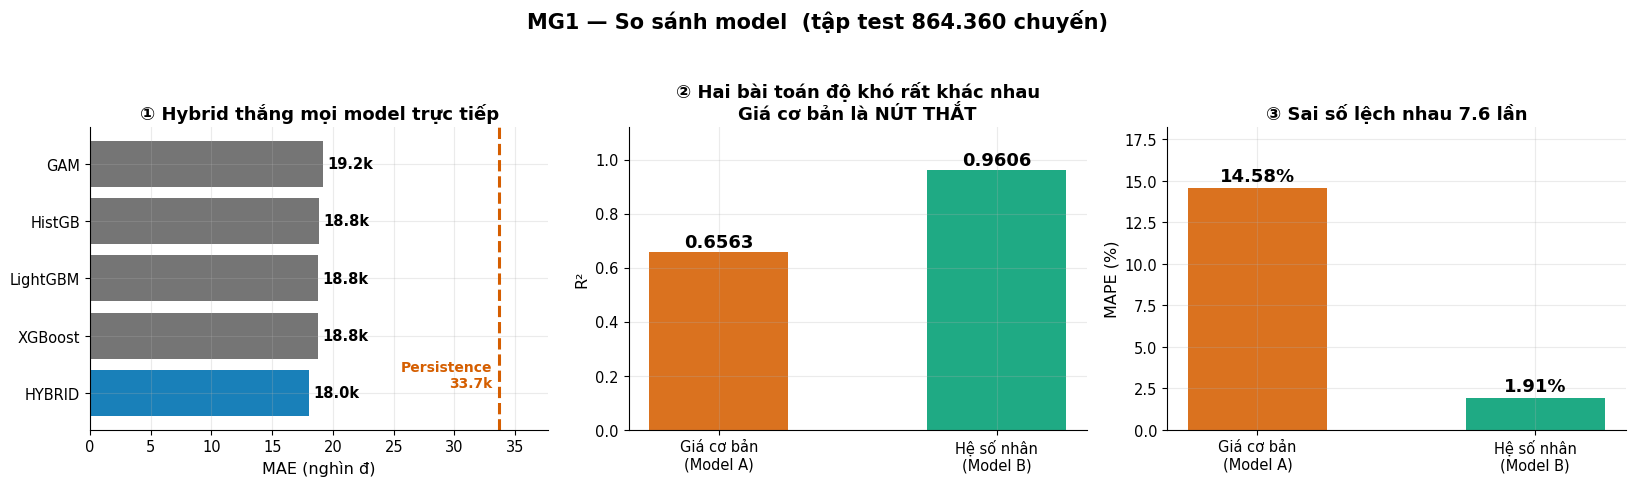

In [3]:
# ═════════ HINH MG1 — so sanh model ═════════
fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.7))

ten_m, mae_m, mau_m = [], [], []
for a, g in pg.groupby("algo", observed=True):
    ten_m.append(a); mae_m.append(do(g.pred, g.target_shown_price)["MAE"]); mau_m.append(MUT)
ten_m.append("GAM"); mae_m.append(do(gam.truc_tiep_pred, gam.gia_that)["MAE"]); mau_m.append(MUT)
ten_m.append("HYBRID"); mae_m.append(mae_hyb); mau_m.append(BLUE)
o = np.argsort(mae_m)
b = ax[0].barh([ten_m[i] for i in o], [mae_m[i]/1000 for i in o],
               color=[mau_m[i] for i in o], alpha=.9)
ax[0].axvline(mae_pers/1000, color=RED, lw=2.2, ls="--")
ax[0].text(mae_pers/1000-.6, .1, f"Persistence\n{mae_pers/1000:.1f}k",
           ha="right", fontsize=10, color=RED, fontweight="bold")
for bb, i in zip(b, o):
    ax[0].text(mae_m[i]/1000+.35, bb.get_y()+bb.get_height()/2,
               f"{mae_m[i]/1000:.1f}k", va="center", fontsize=10.5, fontweight="bold")
ax[0].set_xlim(0, mae_pers/1000*1.12); ax[0].set_xlabel("MAE (nghìn đ)")
ax[0].set_title("① Hybrid thắng mọi model trực tiếp", fontweight="bold")

nh = ["Giá cơ bản\n(Model A)", "Hệ số nhân\n(Model B)"]
r2 = [do(uq.base_pred, uq.base_that)["R2"], do(uq.heso_pred, uq.heso_that)["R2"]]
b2 = ax[1].bar(nh, r2, color=[RED, GREEN], alpha=.88, width=.5)
for bb, v in zip(b2, r2):
    ax[1].text(bb.get_x()+bb.get_width()/2, v+.02, f"{v:.4f}", ha="center",
               fontsize=13, fontweight="bold")
ax[1].set_ylabel("R²"); ax[1].set_ylim(0, 1.12)
ax[1].set_title("② Hai bài toán độ khó rất khác nhau\nGiá cơ bản là NÚT THẮT",
                fontweight="bold")

mp = [do(uq.base_pred, uq.base_that)["MAPE"]*100,
      do(uq.heso_pred, uq.heso_that)["MAPE"]*100]
b3 = ax[2].bar(nh, mp, color=[RED, GREEN], alpha=.88, width=.5)
for bb, v in zip(b3, mp):
    ax[2].text(bb.get_x()+bb.get_width()/2, v+.4, f"{v:.2f}%", ha="center",
               fontsize=13, fontweight="bold")
ax[2].set_ylabel("MAPE (%)"); ax[2].set_ylim(0, max(mp)*1.25)
ax[2].set_title(f"③ Sai số lệch nhau {mp[0]/mp[1]:.1f} lần", fontweight="bold")

fig.suptitle("MG1 — So sánh model  (tập test 864.360 chuyến)",
             fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "MG1_so_sanh_model.png"); plt.show()

## 2. Giá theo thời gian — có dải độ lệch chuẩn

> Theo góp ý của mentor: *"plot price over time hay multiplier over time sẽ informative hơn, với
> có cả vùng standard deviation để đánh giá mức độ uncertainty"*.

**Cách đọc:** đường liền là **trung bình**, vùng tô là **± 1 độ lệch chuẩn**. Nếu vùng tô của model
**hẹp hơn** vùng tô của thực tế ⇒ model **không tái tạo hết** mức dao động thật.

⚠️ Panel ② khống chế **cùng dải quãng đường 4–6 km** để khử ảnh hưởng độ dài chuyến — chỉ còn lại
dao động do **giờ và cung–cầu**, đúng thứ cần đánh giá.

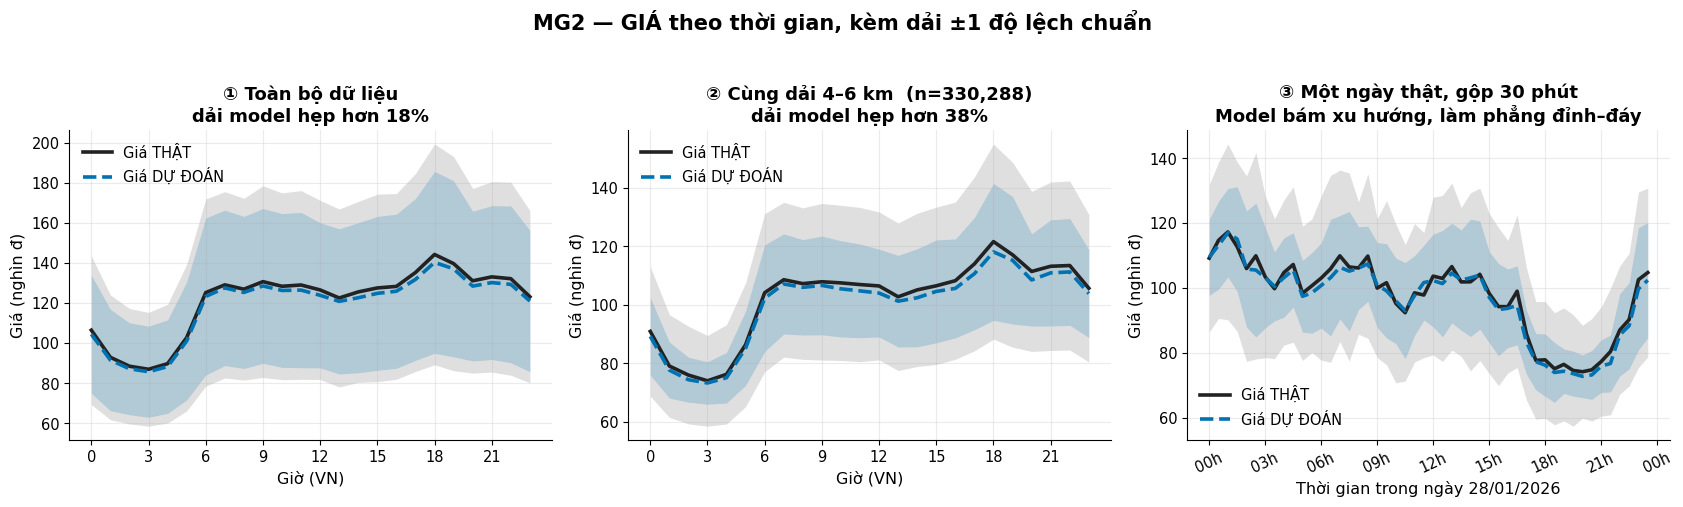

                           std THAT    std MODEL     ty le
----------------------------------------------------------
  Toan bo                   43,433       35,489    81.7%
  Cung dai 4-6km            25,161       15,545    61.8%
  Mot ngay (4-6km)          22,846       13,120    57.4%


In [4]:
# ═════════ HINH MG2 — gia theo thoi gian ═════════
def ve_dai(a, x, tb1, sd1, tb2, sd2, ten1, ten2, c1=INK, c2=BLUE):
    a.fill_between(x, tb1-sd1, tb1+sd1, color=c1, alpha=.14, lw=0)
    a.fill_between(x, tb2-sd2, tb2+sd2, color=c2, alpha=.20, lw=0)
    a.plot(x, tb1, lw=2.6, color=c1, label=ten1)
    a.plot(x, tb2, lw=2.6, color=c2, ls="--", label=ten2)


fig, ax = plt.subplots(1, 3, figsize=(17, 4.9))

# ① Toan bo du lieu, theo gio
g = uq.groupby("gio_vn").agg(t=("gia_that", "mean"), ts=("gia_that", "std"),
                             p=("hybrid_pred", "mean"), ps=("hybrid_pred", "std"))
ve_dai(ax[0], g.index, g.t/1000, g.ts/1000, g.p/1000, g.ps/1000,
       "Giá THẬT", "Giá DỰ ĐOÁN")
ax[0].set_xticks(range(0, 24, 3)); ax[0].set_xlabel("Giờ (VN)")
ax[0].set_ylabel("Giá (nghìn đ)"); ax[0].legend(frameon=False)
ax[0].set_title(f"① Toàn bộ dữ liệu\ndải model hẹp hơn {(1-g.ps.mean()/g.ts.mean())*100:.0f}%",
                fontweight="bold")

# ② Cung dai quang duong 4-6km
band = uq[(uq.quote_distance >= 4) & (uq.quote_distance <= 6)]
gb = band.groupby("gio_vn").agg(t=("gia_that", "mean"), ts=("gia_that", "std"),
                                p=("hybrid_pred", "mean"), ps=("hybrid_pred", "std"))
ve_dai(ax[1], gb.index, gb.t/1000, gb.ts/1000, gb.p/1000, gb.ps/1000,
       "Giá THẬT", "Giá DỰ ĐOÁN")
ax[1].set_xticks(range(0, 24, 3)); ax[1].set_xlabel("Giờ (VN)")
ax[1].set_ylabel("Giá (nghìn đ)"); ax[1].legend(frameon=False)
ax[1].set_title(f"② Cùng dải 4–6 km  (n={len(band):,})\n"
                f"dải model hẹp hơn {(1-gb.ps.mean()/gb.ts.mean())*100:.0f}%",
                fontweight="bold")

# ③ Chuoi thoi gian THAT — mot ngay
ngay = sorted(uq.ngay.unique())[0]
d1 = uq[(uq.ngay == ngay) & (uq.quote_distance.between(4, 6))].copy()
d1["buc"] = d1.target_timestamp.dt.floor("30min")
gt = d1.groupby("buc").agg(t=("gia_that", "mean"), ts=("gia_that", "std"),
                           p=("hybrid_pred", "mean"), ps=("hybrid_pred", "std"))
ve_dai(ax[2], gt.index, gt.t/1000, gt.ts/1000, gt.p/1000, gt.ps/1000,
       "Giá THẬT", "Giá DỰ ĐOÁN")
ax[2].set_xlabel(f"Thời gian trong ngày {ngay:%d/%m/%Y}")
ax[2].set_ylabel("Giá (nghìn đ)"); ax[2].legend(frameon=False)
ax[2].tick_params(axis="x", rotation=25)
import matplotlib.dates as mdates
ax[2].xaxis.set_major_formatter(mdates.DateFormatter("%Hh"))
ax[2].set_title("③ Một ngày thật, gộp 30 phút\nModel bám xu hướng, làm phẳng đỉnh–đáy",
                fontweight="bold")

fig.suptitle("MG2 — GIÁ theo thời gian, kèm dải ±1 độ lệch chuẩn",
             fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "MG2_gia_theo_thoi_gian.png"); plt.show()

print(f"{'':22s} {'std THAT':>12s} {'std MODEL':>12s} {'ty le':>9s}")
print("-" * 58)
for ten, gg in [("Toan bo", g), ("Cung dai 4-6km", gb), ("Mot ngay (4-6km)", gt)]:
    print(f"  {ten:20s} {gg.ts.mean():>11,.0f} {gg.ps.mean():>12,.0f} "
          f"{gg.ps.mean()/gg.ts.mean():>8.1%}")

## 3. Hệ số nhân theo thời gian — cùng cách đọc

Đây là chỗ tương phản mạnh nhất với giá cơ bản.

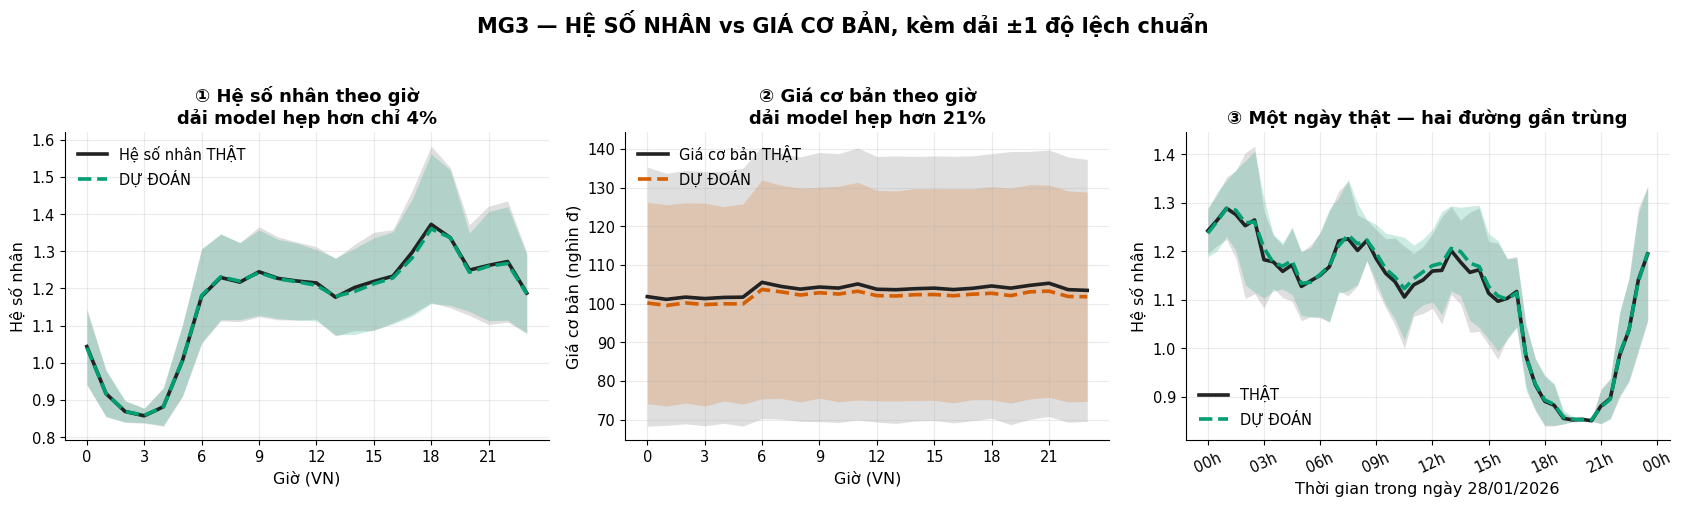

TY LE TAI TAO DAO DONG (std model / std that):
  He so nhan : 96.1%   <- gan nhu hoan hao
  Gia co ban : 79.5%   <- NUT THAT
  Gia cuoi   : 81.7%


In [5]:
# ═════════ HINH MG3 — he so nhan theo thoi gian ═════════
fig, ax = plt.subplots(1, 3, figsize=(17, 4.9))

gm = uq.groupby("gio_vn").agg(t=("heso_that", "mean"), ts=("heso_that", "std"),
                              p=("heso_pred", "mean"), ps=("heso_pred", "std"))
ve_dai(ax[0], gm.index, gm.t, gm.ts, gm.p, gm.ps,
       "Hệ số nhân THẬT", "DỰ ĐOÁN", c2=GREEN)
ax[0].set_xticks(range(0, 24, 3)); ax[0].set_xlabel("Giờ (VN)")
ax[0].set_ylabel("Hệ số nhân"); ax[0].legend(frameon=False)
ax[0].set_title(f"① Hệ số nhân theo giờ\ndải model hẹp hơn chỉ "
                f"{(1-gm.ps.mean()/gm.ts.mean())*100:.0f}%", fontweight="bold")

gbm = uq.groupby("gio_vn").agg(t=("base_that", "mean"), ts=("base_that", "std"),
                               p=("base_pred", "mean"), ps=("base_pred", "std"))
ve_dai(ax[1], gbm.index, gbm.t/1000, gbm.ts/1000, gbm.p/1000, gbm.ps/1000,
       "Giá cơ bản THẬT", "DỰ ĐOÁN", c2=RED)
ax[1].set_xticks(range(0, 24, 3)); ax[1].set_xlabel("Giờ (VN)")
ax[1].set_ylabel("Giá cơ bản (nghìn đ)"); ax[1].legend(frameon=False)
ax[1].set_title(f"② Giá cơ bản theo giờ\ndải model hẹp hơn "
                f"{(1-gbm.ps.mean()/gbm.ts.mean())*100:.0f}%", fontweight="bold")

d1m = uq[uq.ngay == ngay].copy()
d1m["buc"] = d1m.target_timestamp.dt.floor("30min")
gtm = d1m.groupby("buc").agg(t=("heso_that", "mean"), ts=("heso_that", "std"),
                             p=("heso_pred", "mean"), ps=("heso_pred", "std"))
ve_dai(ax[2], gtm.index, gtm.t, gtm.ts, gtm.p, gtm.ps,
       "THẬT", "DỰ ĐOÁN", c2=GREEN)
ax[2].set_xlabel(f"Thời gian trong ngày {ngay:%d/%m/%Y}")
ax[2].set_ylabel("Hệ số nhân"); ax[2].legend(frameon=False)
ax[2].xaxis.set_major_formatter(mdates.DateFormatter("%Hh"))
ax[2].tick_params(axis="x", rotation=25)
ax[2].set_title("③ Một ngày thật — hai đường gần trùng", fontweight="bold")

fig.suptitle("MG3 — HỆ SỐ NHÂN vs GIÁ CƠ BẢN, kèm dải ±1 độ lệch chuẩn",
             fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "MG3_heso_theo_thoi_gian.png"); plt.show()

print("TY LE TAI TAO DAO DONG (std model / std that):")
print(f"  He so nhan : {gm.ps.mean()/gm.ts.mean():.1%}   <- gan nhu hoan hao")
print(f"  Gia co ban : {gbm.ps.mean()/gbm.ts.mean():.1%}   <- NUT THAT")
print(f"  Gia cuoi   : {g.ps.mean()/g.ts.mean():.1%}")

## 4. Hybrid có thắng ở mọi giờ không?

Thắng trung bình chưa đủ — phải kiểm tra có thắng **ổn định** hay chỉ nhờ vài khung giờ.

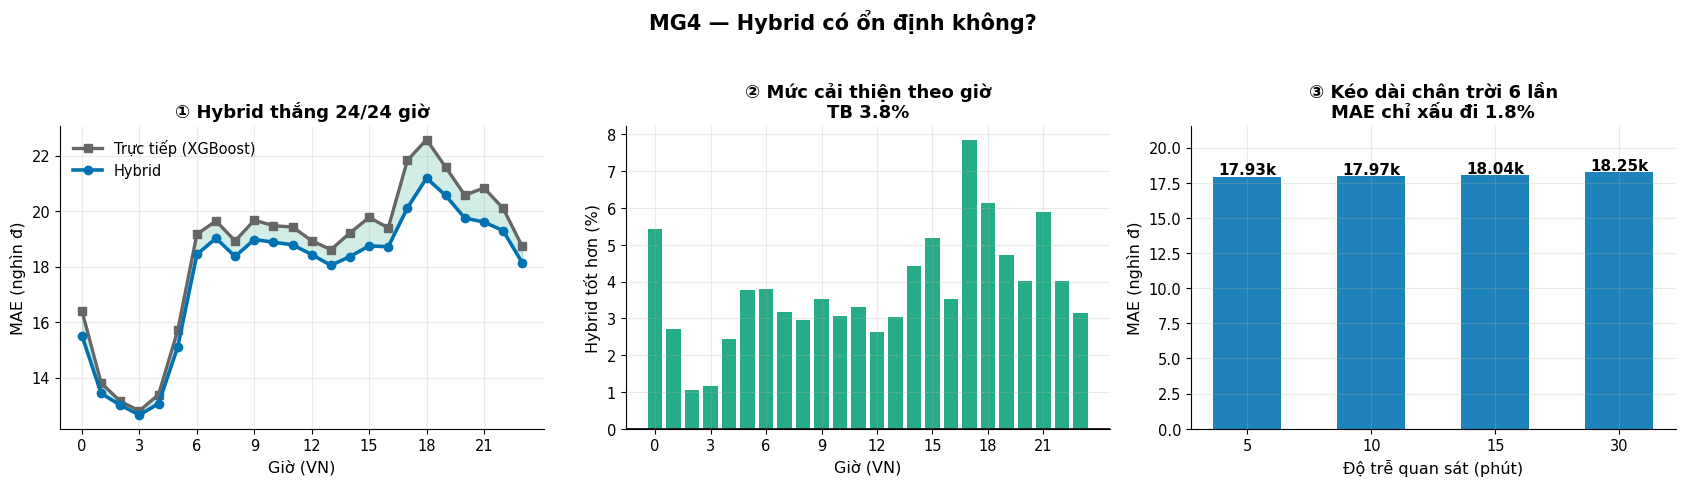

Hybrid thang truc tiep : 24/24 gio  |  cai thien TB 3.8%
MAE theo do tre        : 17,926d (5 phut) -> 18,253d (30 phut)  = +1.8%
=> Model du doan tu CAU TRUC (quang duong, gio, tuyen), khong tu dong luc ngan han.


In [6]:
# ═════════ HINH MG4 — Hybrid vs truc tiep theo gio ═════════
best = pg[pg.algo == "XGBoost"].reset_index(drop=True)
c = pd.DataFrame({"gio": uq.gio_vn.values,
                  "hyb": np.abs(uq.hybrid_pred - uq.gia_that).values,
                  "tt": np.abs(best.pred - best.target_shown_price).values})
gg = c.groupby("gio").mean()
thang = int((gg.hyb < gg.tt).sum())

fig, ax = plt.subplots(1, 3, figsize=(17, 4.7))

ax[0].plot(gg.index, gg.tt/1000, marker="s", lw=2.4, ms=6, color=MUT,
           label="Trực tiếp (XGBoost)")
ax[0].plot(gg.index, gg.hyb/1000, marker="o", lw=2.6, ms=6, color=BLUE,
           label="Hybrid")
ax[0].fill_between(gg.index, gg.hyb/1000, gg.tt/1000, color=GREEN, alpha=.18)
ax[0].set_xticks(range(0, 24, 3)); ax[0].set_xlabel("Giờ (VN)")
ax[0].set_ylabel("MAE (nghìn đ)"); ax[0].legend(frameon=False)
ax[0].set_title(f"① Hybrid thắng {thang}/24 giờ", fontweight="bold")

cai = (gg.tt - gg.hyb)/gg.tt*100
b = ax[1].bar(gg.index, cai, color=[GREEN if v > 0 else RED for v in cai], alpha=.85)
ax[1].axhline(0, color=INK, lw=1.4)
ax[1].set_xticks(range(0, 24, 3)); ax[1].set_xlabel("Giờ (VN)")
ax[1].set_ylabel("Hybrid tốt hơn (%)")
ax[1].set_title(f"② Mức cải thiện theo giờ\nTB {cai.mean():.1f}%", fontweight="bold")

lag = uq.groupby("requested_lag_minutes").apply(
    lambda d: np.abs(d.hybrid_pred - d.gia_that).mean())
b2 = ax[2].bar([str(int(i)) for i in lag.index], lag.values/1000,
               color=BLUE, alpha=.88, width=.55)
for bb, v in zip(b2, lag.values/1000):
    ax[2].text(bb.get_x()+bb.get_width()/2, v+.15, f"{v:.2f}k", ha="center",
               fontsize=11, fontweight="bold")
ax[2].set_xlabel("Độ trễ quan sát (phút)"); ax[2].set_ylabel("MAE (nghìn đ)")
ax[2].set_ylim(0, lag.max()/1000*1.18)
ax[2].set_title(f"③ Kéo dài chân trời 6 lần\nMAE chỉ xấu đi "
                f"{(lag.iloc[-1]/lag.iloc[0]-1)*100:.1f}%", fontweight="bold")

fig.suptitle("MG4 — Hybrid có ổn định không?", fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "MG4_on_dinh.png"); plt.show()

print(f"Hybrid thang truc tiep : {thang}/24 gio  |  cai thien TB {cai.mean():.1f}%")
print(f"MAE theo do tre        : {lag.iloc[0]:,.0f}d (5 phut) -> "
      f"{lag.iloc[-1]:,.0f}d (30 phut)  = +{(lag.iloc[-1]/lag.iloc[0]-1)*100:.1f}%")
print("=> Model du doan tu CAU TRUC (quang duong, gio, tuyen), khong tu dong luc ngan han.")

## 5. Kết luận

In [7]:
print("╔" + "═"*72 + "╗")
print("║" + " CAU PHAN (ii) — KET LUAN ".center(72) + "║")
print("╚" + "═"*72 + "╝")
print()
print(f"  Model tot nhat : HYBRID (HistGB)")
print(f"     MAE  {mae_hyb:,.0f}d   MAPE {do(uq.hybrid_pred, uq.gia_that)['MAPE']:.2%}   "
      f"R2 {do(uq.hybrid_pred, uq.gia_that)['R2']:.4f}")
print(f"     Vuot persistence {(1-mae_hyb/mae_pers)*100:.0f}%  ·  thang truc tiep {thang}/24 gio")
print()
print("  BA KET LUAN:")
print()
print("  1. Tach Hybrid la dung — thang moi model truc tiep, o MOI khung gio.")
print()
print(f"  2. Nut that la GIA CO BAN, khong phai he so nhan:")
print(f"       he so nhan  R2 {do(uq.heso_pred, uq.heso_that)['R2']:.4f}  "
      f"MAPE {do(uq.heso_pred, uq.heso_that)['MAPE']:.2%}  -> gan nhu giai xong")
print(f"       gia co ban  R2 {do(uq.base_pred, uq.base_that)['R2']:.4f}  "
      f"MAPE {do(uq.base_pred, uq.base_that)['MAPE']:.2%}  -> con nhieu du dia?  KHONG")
print()
print(f"  3. DA CHAM TRAN DU LIEU:")
print(f"       4 thuat toan khac han nhau chi chenh "
      f"{(max(mae_algo)/min(mae_algo)-1)*100:.1f}%")
print(f"       Thu hep quang duong xuong 2 MET ma he so bien thien KHONG giam (hinh B5)")
print(f"       -> phan du la NHIEU THAT, khong phai model kem")
print()
print("─"*74)
print("  => Muon tot hon phai co THEM FEATURE, khong phai them thuat toan.")
print("─"*74)

╔════════════════════════════════════════════════════════════════════════╗
║                        CAU PHAN (ii) — KET LUAN                        ║
╚════════════════════════════════════════════════════════════════════════╝

  Model tot nhat : HYBRID (HistGB)
     MAE  18,048d   MAPE 14.74%   R2 0.7297
     Vuot persistence 46%  ·  thang truc tiep 24/24 gio

  BA KET LUAN:

  1. Tach Hybrid la dung — thang moi model truc tiep, o MOI khung gio.

  2. Nut that la GIA CO BAN, khong phai he so nhan:
       he so nhan  R2 0.9606  MAPE 1.91%  -> gan nhu giai xong
       gia co ban  R2 0.6563  MAPE 14.58%  -> con nhieu du dia?  KHONG

  3. DA CHAM TRAN DU LIEU:
       4 thuat toan khac han nhau chi chenh 1.9%
       Thu hep quang duong xuong 2 MET ma he so bien thien KHONG giam (hinh B5)
       -> phan du la NHIEU THAT, khong phai model kem

──────────────────────────────────────────────────────────────────────────
  => Muon tot hon phai co THEM FEATURE, khong phai them thuat toan.
─────────

### Ba kết luận

**1. Tách Hybrid là đúng.** Thắng mọi model trực tiếp, và thắng ở **24/24 giờ** — không phải nhờ
may mắn ở vài khung giờ.

**2. Nút thắt là GIÁ CƠ BẢN, không phải hệ số nhân.** Đây là giá trị lớn nhất của kiến trúc Hybrid:
nó không chỉ cho MAE thấp hơn mà còn **chỉ đúng chỗ nghẽn**.

| | R² | MAPE | Tái tạo dao động |
|---|---:|---:|---:|
| Hệ số nhân | **0,9609** | **1,90%** | ~96% |
| Giá cơ bản | 0,6564 | 14,58% | ~80% |

**3. Đã chạm trần dữ liệu.** Bốn thuật toán khác hẳn nhau về kiến trúc chỉ chênh **1,9%**. Cộng
thêm bằng chứng `B5` — thu hẹp dải quãng đường xuống **2 mét** trên cùng tuyến, cùng loại xe, mà
hệ số biến thiên của giá **không giảm** ⇒ phần dư là **nhiễu thật trong dữ liệu**.

> **Muốn tốt hơn phải có THÊM FEATURE, không phải thêm thuật toán.**

### Nguyên nhân nghi ngờ của sàn nhiễu

Thiếu **trạng thái định giá ẩn** — bộ dữ liệu không lộ ra. Bản `--artifact-profile full` có thêm
bảng `quotes` chứa trường `discount`, đúng thứ nghi ngờ. Đây là một trong các câu hỏi gửi mentor.

### ⚠️ Về con số "tái tạo dao động"

Có **ba cách đo** cho kết quả khác nhau, phải nói rõ đang dùng cách nào:

| Cách đo | Giá cuối |
|---|---:|
| Tỷ lệ std toàn cục | ~84% |
| Tỷ lệ std theo giờ *(dùng trong `MG2` ①)* | ~82% |
| Tỷ lệ std trong cửa sổ hẹp, cùng dải km *(`MG2` ②)* | xem output |

---

## Hình đã sinh

| Hình | Nội dung |
|---|---|
| `MG1_so_sanh_model` | So sánh model · nút thắt giá cơ bản |
| ⭐ `MG2_gia_theo_thoi_gian` | **Giá theo thời gian, dải ±1 std** — theo góp ý mentor |
| ⭐ `MG3_heso_theo_thoi_gian` | **Hệ số nhân vs giá cơ bản**, cùng cách đọc |
| `MG4_on_dinh` | Hybrid thắng 24/24 giờ · độ nhạy theo độ trễ |

## Chi tiết kỹ thuật

| Notebook | Nội dung |
|---|---|
| `../train/01`–`03` | Train Model A · B · baseline trực tiếp |
| `../train/04`–`05` | GAM · GAM trên transformed feature space |
| `04_eval_hybrid` | Ghép A × B |
| `06_plot_uncertainty` · `07_so_sanh_model_theo_thoi_gian` | Trực quan gốc (`U1`–`U4`, `MT1`–`MT5`) |
| `08_truc_quan_GAM` | Đường cong GAM · p-value · bằng chứng tương tác |